In [51]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline
from ydata_profiling import ProfileReport

from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate, cross_val_predict, cross_val_score,StratifiedKFold,train_test_split

from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.metrics import (classification_report, f1_score, recall_score, precision_score, ConfusionMatrixDisplay,
confusion_matrix, roc_auc_score, balanced_accuracy_score)

In [52]:
dfc=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df=dfc.copy()
df.shape

(7043, 21)

In [53]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
#drop high cardinal features

df.drop(columns=['customerID'], inplace=True)

In [55]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(22)

In [57]:
#drop duplicates

before = len(df)
df.drop_duplicates(keep='first', inplace=True)
after = len(df)
print(f"Removed {before - after} duplicate rows. Remaining: {after}")

Removed 22 duplicate rows. Remaining: 7021


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [59]:
#total charges should be converted to numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].isna().sum()  #TotalCharges has 11 missing values

#fill missing values for TotalCharges with mean
df['TotalCharges']=df['TotalCharges'].fillna(0)

#SeniorCitizen is a binary encoded feature ans should not be treated as numerical

df['SeniorCitizen']=df['SeniorCitizen'].astype(str)

In [60]:
#inspecting the categorical columns

catcols=df.select_dtypes(include='object')
for i in catcols:
    print(f'features: {i}, values: {df[i].unique()}')
    print('-----------------------------')

features: gender, values: ['Female' 'Male']
-----------------------------
features: SeniorCitizen, values: ['0' '1']
-----------------------------
features: Partner, values: ['Yes' 'No']
-----------------------------
features: Dependents, values: ['No' 'Yes']
-----------------------------
features: PhoneService, values: ['No' 'Yes']
-----------------------------
features: MultipleLines, values: ['No phone service' 'No' 'Yes']
-----------------------------
features: InternetService, values: ['DSL' 'Fiber optic' 'No']
-----------------------------
features: OnlineSecurity, values: ['No' 'Yes' 'No internet service']
-----------------------------
features: OnlineBackup, values: ['Yes' 'No' 'No internet service']
-----------------------------
features: DeviceProtection, values: ['No' 'Yes' 'No internet service']
-----------------------------
features: TechSupport, values: ['No' 'Yes' 'No internet service']
-----------------------------
features: StreamingTV, values: ['No' 'Yes' 'No internet

In [61]:
#inspecting data imbalance. we have seriously imbalanced data
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True).round(3)

Churn
No     0.736
Yes    0.264
Name: proportion, dtype: float64

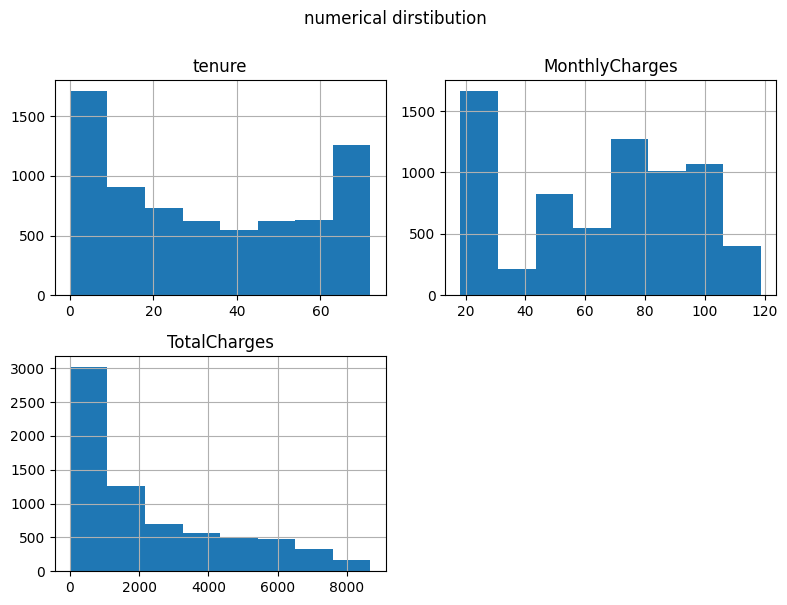

In [62]:
#inspecting numerical distribution

df.hist(figsize=(8,6), bins=8)
plt.suptitle('numerical dirstibution', y=1.0)
plt.tight_layout()
plt.show()

In [63]:
#inspecting for skewness

df.skew(numeric_only=True)

tenure            0.235542
MonthlyCharges   -0.224097
TotalCharges      0.959910
dtype: float64

In [64]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7021.0,32.469449,24.534965,0.00,9.00,29.00,55.0,72.00
MonthlyCharges,7021.0,64.851894,30.069001,18.25,35.75,70.40,89.9,118.75
TotalCharges,7021.0,2286.765026,2266.855057,0.00,403.35,1400.55,3801.7,8684.80


### FEATURE ENGINEERING & PREPROCESSING

In [65]:
'''Raw tenure (0–72 months) as a continuous variable hides a non-linear pattern — 
urn risk is highest in months 1–12, drops in the middle, and rises again near contract end. '''

def tenure_bucket(tenure):
    if tenure<=12: return 'new'
    elif tenure <36: return 'growing'
    elif tenure< 60: return 'loyal'
    else: return 'champion'
df['tenure_group']=df['tenure'].apply(tenure_bucket)


'''Monthly vs Total charge gap
If someone's monthly charge is high but their total charges are low relative to tenure, 
they may be on an expensive newer plan and feel overcharged:'''
df['charge_gap']=(df['MonthlyCharges']*df['tenure'])-df['TotalCharges']

'''No online security + no tech support. customers with no support are more likely to churn'''
df['no_support']= ((df['OnlineSecurity']=='No') & ( df['TechSupport']=='No')
                   & (df['DeviceProtection']=='No') & (df['OnlineBackup']=='No')).astype(int).astype(str)

'''Paperless billing flag interaction with senior citizen---Senior citizens on paperless billing churn more'''
df['senior_paperless']=((df['SeniorCitizen']=='1')&(df['PaperlessBilling']=='Yes')).astype(int).astype(str)

''' Charge-to-tenure ratio---A customer paying a lot relative to how long they've been with you is at high risk '''
df['charge_per_month']=df['TotalCharges']/df['tenure'].clip(lower=1)


#splitting x and y
x=df.drop(columns=['Churn'])

le=LabelEncoder()
y=le.fit_transform(df['Churn'])

#identify binary vs non-binary features(multi-class features)
catcols=x.select_dtypes(include='object').columns
for col in catcols:
    x[col] = x[col].str.strip()
numcols=x.select_dtypes(include=np.number).columns
binary_columns=[col for col in catcols if set(x[col].unique()).issubset({'No','Yes', 'Male', 'Female', '0','1'})]

non_binary_columns=[col for col in catcols if col not in binary_columns ]

def mapped_binary (df, col):
    mapping={'No': 0,'Yes': 1, 'Male':1, 'Female':0, '0':0,'1':1}
    df[col]=df[col].map(mapping)
    return df
for i in binary_columns:
    x=  mapped_binary(x, i)  

#NEW TRAIN AND TEST FOR SHAP AND DEPLOYMENT
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.25, stratify=y, random_state=42)

#PREPROCESSING PIPELINE
numerical_pipeline=Pipeline(steps=[
    ('scaler', StandardScaler())
])

nonBinary_pipeline=Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first',sparse_output=False))
])

preprocessing=ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numcols),
    ('nonBinary_pipeline', nonBinary_pipeline, non_binary_columns),
    ('binary_columns', 'passthrough', binary_columns)
], remainder='drop')

### base model selection

In [66]:
#model

models={
    'lr':LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42, solver='lbfgs'),
    'rf':RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=300, max_depth=10, n_jobs=-1),
    'xgb':XGBClassifier(n_estimators=300, random_state=42, max_depth=6,learning_rate=0.05, eval_metric='logloss',scale_pos_weight = 2.8, n_jobs=1),
    'svm':SVC(class_weight='balanced', probability=True, random_state=42, kernel='rbf', gamma=0.01)
}

#cross validation
cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

print("\nBase models configured.")


Base models configured.


In [67]:
# Calculate correct scale_pos_weight for XGBoost
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
spw = round(neg_count / pos_count, 2)
print(f"optimum XGBoost scale_pos_weight should be: {spw}")

optimum XGBoost scale_pos_weight should be: 2.78


### generate meta models and stacks

In [68]:
#FIT BASE MODEL ON TRAINING DATA ONLY
'''so we have actual fitted model objects saved for streamit to use later '''

fitted_pipelines={}

stack_df_train=pd.DataFrame(index=X_train.index)

print('\nTrainig base models...')
for name, model in models.items():
    pipe=Pipeline(steps=[
        ('preprocessing',preprocessing),
        ('models', model)
    ])
    #OOF predictions for trainig data only (for meta model training)
    oof_probs =cross_val_predict(pipe,X_train,y_train,cv=cv, method='predict_proba', n_jobs=-1)[:,1]

   # Verify lengths match before assignment
    if len(oof_probs) != len(X_train):
        print(f"Warning: Length mismatch for {name}. Expected {len(X_train)}, got {len(oof_probs)}")
        continue
    
    # Assign predictions to DataFrame with original index preserved
    stack_df_train[f'{name}_prob'] = oof_probs

    #FIT pipeline on all xtrain...needed for deployment
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"  ✓ {name} done")

# Attach true labels - preserve original index
stack_df_train['y'] = y_train

#BUILD STACK FEATURES FOR THE TEST SET TOO
stack_df_test=pd.DataFrame(index=X_test.index)
for name, pipe in fitted_pipelines.items():
    stack_df_test[f'{name}_prob']=pipe.predict_proba(X_test)[:,1]

print ('\nstacked feature matrices built for train and test.')



Trainig base models...
  ✓ lr done
  ✓ rf done
  ✓ xgb done
  ✓ svm done

stacked feature matrices built for train and test.


In [92]:
#EVALUATION METRICS FOR BASE MODELS

# Define scoring functions
scoring = {
    'f1': f1_score,
    'precision': precision_score,
    'recall': recall_score,
    'roc_auc': roc_auc_score,
    'balanced_accuracy': balanced_accuracy_score
}

# Evaluate each base model on the test set
results = {}
for name, pipe in fitted_pipelines.items():
    # Get predicted probabilities and labels
    probs = pipe.predict_proba(X_test)[:,1]
    preds = (probs > 0.5).astype(int)   # threshold at 0.5
    
    # Compute metrics
    results[name] = {
        m: (f(y_test, preds) if m!='roc_auc' else f(y_test, probs))
        for m,f in scoring.items()
    }
#convert to dataframe
results_df = pd.DataFrame(results).T
# Round metrics to 2 decimal places
results_df = results_df.round(3)
# Sort by F1 score
results_df = results_df.sort_values(by='f1', ascending=False)

results_df

,f1,precision,recall,roc_auc,balanced_accuracy
rf,0.638,0.578,0.713,0.845,0.763
xgb,0.617,0.555,0.694,0.839,0.747
lr,0.616,0.506,0.787,0.842,0.755
svm,0.610,0.666,0.562,0.840,0.731


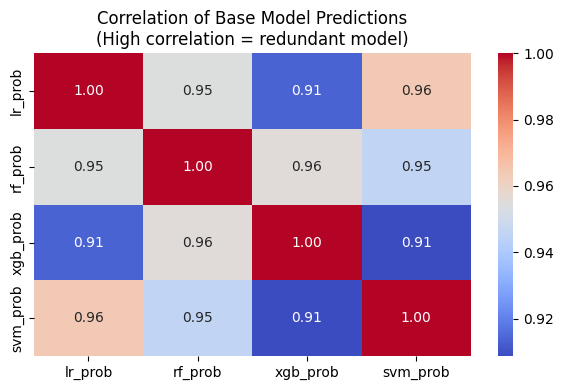

In [70]:
#visualizing correlation among predicted probalilities

plt.figure(figsize=(6,4))
corr=stack_df_test.corr(numeric_only=True)
sb.heatmap( corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation of Base Model Predictions\n(High correlation = redundant model)")
plt.tight_layout()
square= True
plt.show()

In [71]:
# Get feature importances from RandomForest

# Example: feature importance from RandomForest base model
rf_model = fitted_pipelines['rf'].named_steps['models']  # get the RF classifier
importances = rf_model.feature_importances_

feature_names = fitted_pipelines['rf'].named_steps['preprocessing'].get_feature_names_out()

# Match importance values to feature names
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Show only top 15
top15 = importance_series.head(15)

print("\nTop 15 Feature Importances (Random Forest):")
print(top15.round(3))

# Visualization
plt.figure(figsize=(12,8))
top15.plot(kind='bar', color='steelblue')
plt.title('Top 15 features - Random Forest base model')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('img/random forest feature imporance for base model.png')
plt.close()
#plt.show()

print ('\nsaved plot for Top 15 Feature Importances (Random Forest)\n')


Top 15 Feature Importances (Random Forest):
num__tenure                                                0.132
num__TotalCharges                                          0.103
nonBinary_pipeline__Contract_Two year                      0.086
num__charge_per_month                                      0.081
num__MonthlyCharges                                        0.079
nonBinary_pipeline__InternetService_Fiber optic            0.065
num__charge_gap                                            0.059
nonBinary_pipeline__tenure_group_new                       0.045
nonBinary_pipeline__PaymentMethod_Electronic check         0.039
nonBinary_pipeline__Contract_One year                      0.029
binary_columns__no_support                                 0.025
nonBinary_pipeline__OnlineSecurity_Yes                     0.020
nonBinary_pipeline__TechSupport_Yes                        0.019
binary_columns__PaperlessBilling                           0.016
nonBinary_pipeline__StreamingMovies_No intern

In [72]:
#TRAIN META MODEL (FINAL FIT)


x_stacked_train=stack_df_train.drop(columns=['y'])
y_stacked_train=y_train.tolist()

#meta model
meta_model=GradientBoostingClassifier( n_estimators=300, max_depth=5,learning_rate=0.05,random_state=42)
meta_model.fit(x_stacked_train, y_stacked_train) #fit , saved for SHAP

# Find best threshold for F1
meta_thresholds= np.arange(0.1, 0.9, 0.01)
train_meta_probs=meta_model.predict_proba(x_stacked_train)[:,1]
f1s = [f1_score(y_stacked_train, train_meta_probs > t) for t in meta_thresholds]
meta_best_t = meta_thresholds[np.argmax(f1s)]
print(f"\nbest threshold found for meta model: {meta_best_t: .2f}.")

#FINAL EVALUATION ON TEST SET
final_test_probs=meta_model.predict_proba(stack_df_test)[:,1]
final_test_preds=(final_test_probs>meta_best_t).astype(int)


best threshold found for meta model:  0.37.


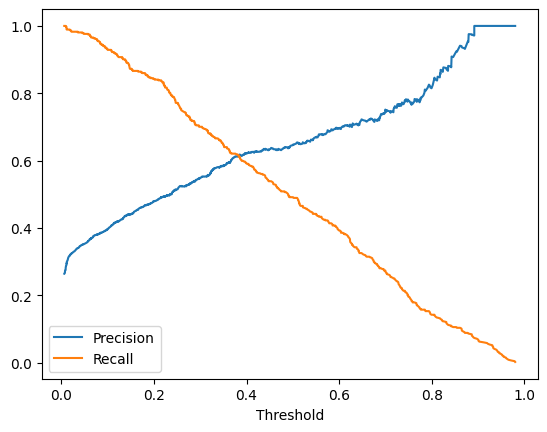

In [73]:
#finding optimum threshold for precison and recall

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, final_test_probs)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()


In [74]:
#MODEL EVALUATION METRICS

print('FINAL MODEL EVALUATION ON HELD OUT TEST SET\n')
print(classification_report(y_test, final_test_preds, target_names=['No Churn', 'Churn']))
print('=========================')
print('precision score: ',precision_score(y_test,final_test_preds))
print('=========================')
print('recall score: ',recall_score(y_test,final_test_preds))
print('=========================')
print('f1 score: ',f1_score(y_test,final_test_preds))
print('=========================')
print('Balanced Accuracy:', balanced_accuracy_score(y_test,final_test_preds))
print('=========================')
print ('roc auc score: ', roc_auc_score(y_test, final_test_probs))
print('=========================')
print('confusion martix: ','\n' ,confusion_matrix(y_test,final_test_preds))
print('=========================')
print ('best threshold: ', meta_best_t)

FINAL MODEL EVALUATION ON HELD OUT TEST SET

              precision    recall  f1-score   support

    No Churn       0.86      0.86      0.86      1292
       Churn       0.61      0.62      0.61       464

    accuracy                           0.79      1756
   macro avg       0.74      0.74      0.74      1756
weighted avg       0.80      0.79      0.79      1756

precision score:  0.6075949367088608
recall score:  0.6206896551724138
f1 score:  0.6140724946695096
Balanced Accuracy: 0.7383634034376001
roc auc score:  0.8365129910857265
confusion martix:  
 [[1106  186]
 [ 176  288]]
best threshold:  0.3699999999999999


### saving the model

In [75]:
import joblib
from joblib import dump
!pip freeze > requirements.txt
joblib.dump({
    'fitted_pipelines':fitted_pipelines,
    'meta_model':meta_model,
    'label_encoders':le,
    'preprocessor': preprocessing,
    'threshold':meta_best_t,
    'feature_columns': list(x.columns),
    'numcols': list(numcols),
    'binary_columns': binary_columns,
    'non_binary_columns': non_binary_columns,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'stack_df_train': stack_df_train.drop(columns=['y']),
    'stack_df_test': stack_df_test,
}, 'chun_model_bundle.pkl')

print('\n✓ saved chun model mundle. ready for SHAP and Streamlit')


C:\Users\HP\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=22>
  res = process_handler(cmd, _system_body)
C:\Users\HP\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=23>
  res = process_handler(cmd, _system_body)
C:\Users\HP\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=24>
  res = process_handler(cmd, _system_body)



✓ saved chun model mundle. ready for SHAP and Streamlit


### SHAP explainability

In [76]:
#LEVEL A - SHAP ON THE BASE MODEL - we pick random forest since tree based models are faster

import joblib,shap
bundle=joblib.load('chun_model_bundle.pkl')

fitted_pipelines=bundle['fitted_pipelines']
meta_model=bundle['meta_model']
X_train=bundle['X_train']
X_test=bundle['X_test']
stack_df_train=bundle['stack_df_train']
stack_df_test=bundle['stack_df_test']
numcols=bundle['numcols']
binary_columns=bundle['binary_columns']
non_binary_columns=bundle['non_binary_columns']

print('bundle loaded. Test shape :', X_test.shape )

bundle loaded. Test shape : (1756, 24)


In [77]:
print('='*55)
print ('SHAP ON THE BASE MODEL (raw features)')
print('='*55)

best_pipeline=fitted_pipelines['rf'] #full pipeline (preprocessing + model)

'''SHAP needs to see data after preprocessing (scaling + onehot)'''
preprocessor=best_pipeline.named_steps['preprocessing']
rf_model=best_pipeline.named_steps['models']

#transform train/test through same fitted preprocessor
X_trained_transformed=preprocessor.transform(X_train)
X_test_transformed=preprocessor.transform(X_test)

#get readable column names after onehotencoding
feature_names=(
    list(numcols)+
    list(preprocessor.named_transformers_['nonBinary_pipeline']
        .named_steps['onehot'].get_feature_names_out(non_binary_columns))+ list(binary_columns)
)
#wraped transformed arrays back into dataframe with real column names
X_train_df=pd.DataFrame(X_trained_transformed, columns=feature_names)
X_test_df=pd.DataFrame(X_test_transformed, columns=feature_names)


SHAP ON THE BASE MODEL (raw features)


In [78]:
#Treeexplainer is fast and works well with tree based models
explainer_base=shap.TreeExplainer(rf_model)

#calculate shap values for the test data(unseen data)
shap_values_base=explainer_base.shap_values(X_test_df)

if isinstance (shap_values_base,list):
    shap_values_base_churn = shap_values_base[1] #class 1= churn
elif len(shap_values_base.shape) == 3:
    shap_values_base_churn = shap_values_base[:, :, 1]
    
else:
    # Binary models returning direct matrix
    shap_values_base_churn = shap_values_base
    print("SHAP values computed  for: ", X_test_df.shape[0], 'test customers')
    print ('each customer has: ', X_test_df.shape[1], 'feature contribution')


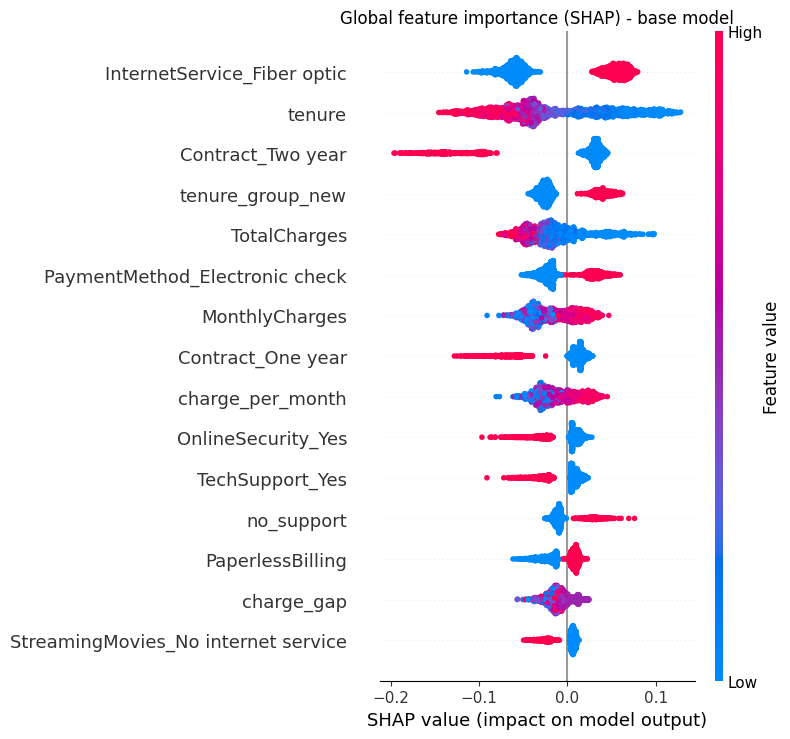

saved SHAP golbal summary.png' 


In [86]:
'''GLOBAL explanation: what matters most. across all  customers, wich features contribute most to churn '''
# SHAP summary plot with top 15 features
plt.figure(figsize=(12,8))
shap.summary_plot(
    shap_values_base_churn,
    X_test_df,
    show=False,
    max_display=15
)

plt.title('Global feature importance (SHAP) - base model')
plt.tight_layout()
plt.savefig('img/SHAP_global_summary.png', dpi=120, bbox_inches='tight')
plt.show()
#plt.close()

print ("saved SHAP golbal summary.png' ")

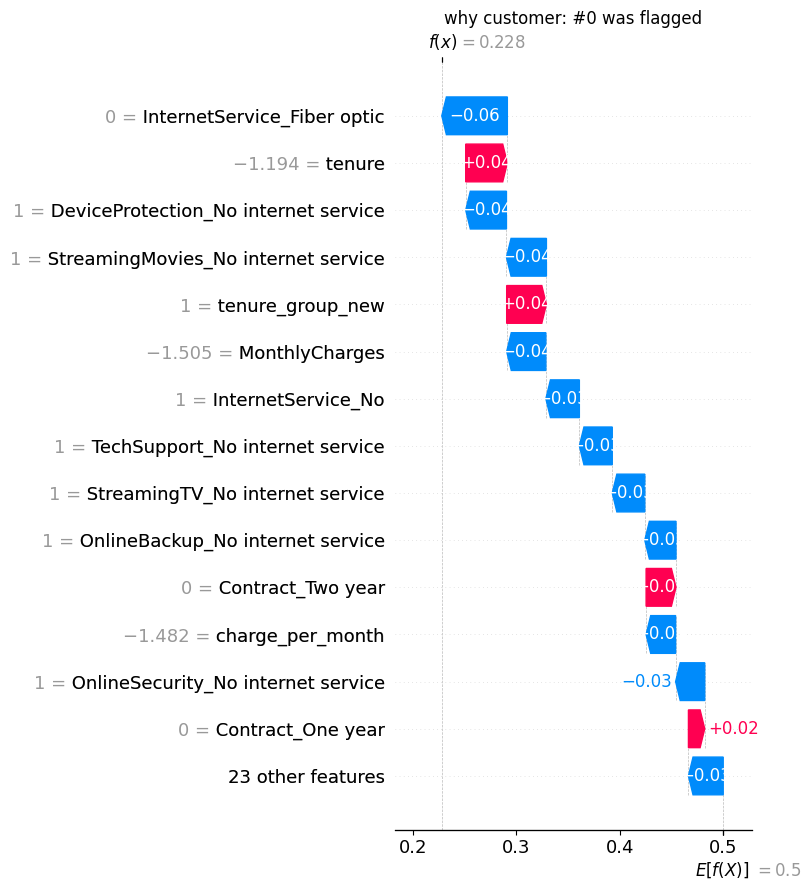

saved shap individual customer.png


In [88]:
#LOCAL EXPLANATION--why did this customer get flagged? (just for one customer)


customer_index = 0  # explain the first customer

# Use shap.plots.waterfall with a single row of shap values
shap.plots.waterfall(
    shap.Explanation(
        # Select the SHAP values for the positive class (index 1) for churn prediction
        values=shap_values_base_churn[customer_index],
        base_values=(
            explainer_base.expected_value[1] 
            if isinstance(explainer_base.expected_value, np.ndarray) 
            else explainer_base.expected_value
        ),
        data=X_test_df.iloc[customer_index],
        feature_names=feature_names
    ),
    show=False,
    max_display=15
)

plt.title(f'why customer: #{customer_index} was flagged')
plt.tight_layout()
plt.savefig('img/shap individual customer.png', dpi=120, bbox_inches='tight')
plt.show()
#plt.close()
print('saved shap individual customer.png')


shap on the meata model (which model mattered)


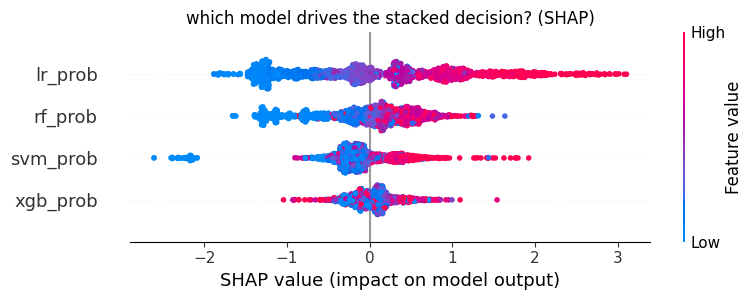

save meta model summary.png


In [87]:
#SHAP ON THE META MODEL

print ("\n" + "="*50)
print("shap on the meata model (which model mattered)")
print ("=" *50)

explainer_meta=shap.TreeExplainer(meta_model)
shap_values_meta=explainer_meta.shap_values(stack_df_test)

if isinstance(shap_values_meta, list):
    shape_values_meta_churn=shape_values_meta[1]
else:
    shape_values_meta_churn=shap_values_meta

plt.figure()
shap.summary_plot(
    shape_values_meta_churn,
    stack_df_test,
    show=False
)

plt.title('which model drives the stacked decision? (SHAP)')
plt.tight_layout()
plt.savefig('img/shap meta model summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('save meta model summary.png')

In [82]:
#SAVE EVERYTHING NEEDED FOR STREAMLIT

!pip freeze > requirements.txt

joblib.dump({
     'explainer_base':explainer_base,
    'feature_names' :feature_names,
    'explainer_meta' :explainer_meta,
}, 'shap_artifacts.pkl')

print('\nsaved shap_artefacts.pkl. (ready for streamlit to reuse)')
print ('\nDONE. open the png folder  to see the SHAP plot')



C:\Users\HP\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=22>
  res = process_handler(cmd, _system_body)
C:\Users\HP\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=23>
  res = process_handler(cmd, _system_body)
C:\Users\HP\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=24>
  res = process_handler(cmd, _system_body)



saved shap_artefacts.pkl. (ready for streamlit to reuse)

DONE. open the png folder  to see the SHAP plot


In [83]:
%%writefile churn_prediction_app.py

# ============================================================
# STREAMLIT APP — CHURN PREDICTION WITH SHAP EXPLANATION
# ============================================================
import pandas as pd
import numpy as np
import streamlit as st
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns


st.set_page_config(
    page_title="Customer Churn Predictor",
    page_icon="📉",
    layout="centered"
)
 
 
# ─────────────────────────────────────────────
# LOAD MODEL ARTIFACTS (cached so it only loads once, not on every click)
# ─────────────────────────────────────────────

 
@st.cache_resource
def load_artifacts():
    """Load the trained model bundle and SHAP explainers from disk."""
    # NOTE: these files must sit in the SAME folder you run
    # `streamlit run app.py` from. If you get FileNotFoundError,
    # that's almost always the cause — check your terminal's
    # current directory with `pwd` (Mac/Linux) or `cd` (Windows).
    bundle = joblib.load('chun_model_bundle.pkl')
    shap_artifacts = joblib.load('shap_artifacts.pkl')
    return bundle, shap_artifacts
 
bundle, shap_artifacts = load_artifacts()
 
# Unpack everything we need from the saved bundle
fitted_pipelines    = bundle['fitted_pipelines']      # dict of {name: fitted sklearn Pipeline}
meta_model           = bundle['meta_model']            # fitted GradientBoosting meta model
threshold             = bundle['threshold']             # best F1 threshold found during training
numcols               = bundle['numcols']
binary_columns        = bundle['binary_columns']
non_binary_columns    = bundle['non_binary_columns']
 
explainer_base   = shap_artifacts['explainer_base']    # SHAP explainer for the RF base model
feature_names    = shap_artifacts['feature_names']     # readable column names after preprocessing
 
 
# ─────────────────────────────────────────────
# APP TITLE & DESCRIPTION
# ─────────────────────────────────────────────
st.title("📉 Customer Churn Predictor")
st.write(
    "Fill in a customer's details below to predict their churn risk "
    "and see exactly which factors are driving that prediction."
)
 
st.divider()
 
 
# ─────────────────────────────────────────────
# INPUT FORM
# ─────────────────────────────────────────────
# st.form groups all inputs together so the app only re-runs
# ONCE when the user clicks "Predict" — not after every single
# field change, which would feel sluggish.
 
with st.form("customer_form"):
    st.subheader("Customer Details")
 
    # Using columns to arrange the form neatly side by side
    col1, col2 = st.columns(2)
 
    with col1:
        gender = st.selectbox("Gender", ["Male", "Female"])
        senior_citizen = st.selectbox("Senior Citizen", ["No", "Yes"])
        partner = st.selectbox("Has Partner", ["Yes", "No"])
        dependents = st.selectbox("Has Dependents", ["Yes", "No"])
        tenure = st.slider("Tenure (months)", 0, 72, 12)
        phone_service = st.selectbox("Phone Service", ["Yes", "No"])
        multiple_lines = st.selectbox("Multiple Lines", ["Yes", "No", "No phone service"])
        internet_service = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
        online_security = st.selectbox("Online Security", ["Yes", "No", "No internet service"])
        online_backup = st.selectbox("Online Backup", ["Yes", "No", "No internet service"])
 
    with col2:
        device_protection = st.selectbox("Device Protection", ["Yes", "No", "No internet service"])
        tech_support = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])
        streaming_tv = st.selectbox("Streaming TV", ["Yes", "No", "No internet service"])
        streaming_movies = st.selectbox("Streaming Movies", ["Yes", "No", "No internet service"])
        contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
        paperless_billing = st.selectbox("Paperless Billing", ["Yes", "No"])
        payment_method = st.selectbox(
            "Payment Method",
            ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"]
        )
        monthly_charges = st.number_input("Monthly Charges ($)", min_value=0.0, max_value=200.0, value=70.0)
        total_charges = st.number_input("Total Charges ($)", min_value=0.0, max_value=10000.0, value=840.0)
 
    # The submit button — clicking this triggers everything below
    submitted = st.form_submit_button("🔮 Predict Churn Risk", use_container_width=True)
 
 
# ─────────────────────────────────────────────
# WHEN THE USER SUBMITS THE FORM
# ─────────────────────────────────────────────
if submitted:
 
    # ───── Step 1: Build a single-row DataFrame from form inputs ─────
    raw_input = pd.DataFrame([{
        'gender': gender,
        'SeniorCitizen': '1' if senior_citizen == 'Yes' else '0',  # match training format (string)
        'Partner': partner,
        'Dependents': dependents,
        'tenure': tenure,
        'PhoneService': phone_service,
        'MultipleLines': multiple_lines,
        'InternetService': internet_service,
        'OnlineSecurity': online_security,
        'OnlineBackup': online_backup,
        'DeviceProtection': device_protection,
        'TechSupport': tech_support,
        'StreamingTV': streaming_tv,
        'StreamingMovies': streaming_movies,
        'Contract': contract,
        'PaperlessBilling': paperless_billing,
        'PaymentMethod': payment_method,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
    }])
 
    # ───── Step 2: Recreate the SAME engineered features used in training ─────
    def tenure_bucket(t):
        if t <= 12: return 'new'
        elif t < 36: return 'growing'
        elif t < 60: return 'loyal'
        else: return 'champion'
 
    raw_input['tenure_group'] = raw_input['tenure'].apply(tenure_bucket)
    raw_input['charge_gap'] = (raw_input['MonthlyCharges'] * raw_input['tenure']) - raw_input['TotalCharges']
    raw_input['no_support'] = (
        (raw_input['OnlineSecurity'] == 'No') & (raw_input['TechSupport'] == 'No') &
        (raw_input['DeviceProtection'] == 'No') & (raw_input['OnlineBackup'] == 'No')
    ).astype(int).astype(str)
    raw_input['senior_paperless'] = (
        (raw_input['SeniorCitizen'] == '1') & (raw_input['PaperlessBilling'] == 'Yes')
    ).astype(int).astype(str)
    raw_input['charge_per_month'] = raw_input['TotalCharges'] / raw_input['tenure'].clip(lower=1)
 
    # ───── Step 2b: Map binary text columns to 0/1 — THIS WAS MISSING ─────
    # During training, every binary categorical column (gender, Partner,
    # Dependents, PhoneService, SeniorCitizen, OnlineSecurity, etc.) was
    # converted from text ('Yes'/'No'/'Male'/'Female'/'0'/'1') into actual
    # integers 0/1 BEFORE it ever reached the pipeline. The pipeline's
    # ColumnTransformer treats binary columns as 'passthrough' — meaning
    # it does ZERO conversion itself. It assumes the values are already
    # numeric by the time they arrive.
    #
    # Streamlit was sending raw text straight into predict_proba(), which
    # is exactly why LogisticRegression crashed inside numpy.asarray() —
    # it tried to convert strings like 'Male' or 'No' into floats and failed.
    #
    # FIX: replicate the EXACT same mapping used in training, applied to
    # the SAME set of binary columns, before calling predict_proba().
 
    binary_columns = bundle['binary_columns']   # loaded from the saved bundle — must match training exactly
 
    def mapped_binary(df, col):
        """Identical to the function used during training — must stay in sync."""
        mapping = {'No': 0, 'Yes': 1, 'Male': 1, 'Female': 0, '0': 0, '1': 1}
        df[col] = df[col].map(mapping)
        return df
 
    for col in binary_columns:
        raw_input = mapped_binary(raw_input, col)
 
    # ───── Step 2c: Guard against silent NaN from unmapped categories ─────
    # If a form value isn't in the mapping dict (e.g. "No internet service"
    # selected for a column your TRAINING DATA never saw as binary), .map()
    # silently produces NaN instead of raising an error. NaN reaches
    # numpy.asarray() inside the model and crashes with the exact same
    # error you saw — but with no indication of WHICH column caused it.
    # This check fails loudly and tells you exactly which column is wrong.
    nan_cols = raw_input[binary_columns].columns[raw_input[binary_columns].isna().any()].tolist()
    if nan_cols:
        st.error(
            f"⚠️ Input error: these fields have a value that wasn't seen "
            f"during training as binary: {nan_cols}. "
            f"Check the form options for these fields."
        )
        st.stop()   # halts execution here — prevents the crash below
 
    # Sanity check (optional but recommended while debugging):
    # st.write(raw_input.dtypes)  ← uncomment to inspect dtypes if errors persist
 
    # ───── Step 3: Run through EACH base model pipeline ─────
    base_probs = {}
    for name, pipe in fitted_pipelines.items():
        prob = pipe.predict_proba(raw_input)[:, 1][0]   # probability of churn (class 1)
        base_probs[f'{name}_prob'] = prob
 
    # ───── Step 4: Feed those base probabilities into the meta model ─────
    stack_input = pd.DataFrame([base_probs])
    final_prob = meta_model.predict_proba(stack_input)[:, 1][0]
    final_pred = int(final_prob > threshold)
 
    # ───── Step 5: Display the prediction ─────
    st.divider()
    st.subheader("Prediction Result")
 
    risk_pct = final_prob * 100
 
    if final_pred == 1:
        st.error(f"⚠️ **High Churn Risk** — {risk_pct:.1f}% probability")
    else:
        st.success(f"✅ **Low Churn Risk** — {risk_pct:.1f}% probability")
 
    st.progress(min(final_prob, 1.0))
    st.caption(f"Decision threshold used: {threshold:.2f} (probabilities above this are flagged as churn risk)")
 
    # ───── Step 6: SHAP explanation for THIS customer ─────
    st.divider()
    st.subheader("Why this prediction? (SHAP Explanation)")
    st.write(
        "The chart below shows which factors pushed this customer's "
        "risk score up (red) or down (blue), using our best-performing "
        "base model (Random Forest) for interpretability."
    )
 
    # Transform this customer's data through the SAME preprocessing
    # pipeline used by the Random Forest model, so SHAP sees exactly
    # what the model sees.
    rf_pipeline = fitted_pipelines['rf']
    preprocessor = rf_pipeline.named_steps['preprocessing']
    x_transformed = preprocessor.transform(raw_input)
    x_transformed_df = pd.DataFrame(x_transformed, columns=feature_names)
 
    # Compute SHAP values for this single customer
    shap_values = explainer_base.shap_values(x_transformed_df)
 
    # Handle SHAP output shape — varies by SHAP version / model type
    if isinstance(shap_values, list):
        shap_row = shap_values[1][0]
        expected_val = explainer_base.expected_value[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_row = shap_values[0, :, 1]
        expected_val = explainer_base.expected_value[1]
    else:
        shap_row = shap_values[0]
        expected_val = explainer_base.expected_value
 
    # Draw the waterfall plot and display it inside the Streamlit app
    fig, ax = plt.subplots()
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_row,
            base_values=expected_val,
            data=x_transformed_df.iloc[0].values,
            feature_names=feature_names
        ),
        show=False,
        max_display=10
    )
    st.pyplot(fig, bbox_inches='tight')
    plt.close(fig)
 
    st.caption(
        "Red bars push the prediction toward churn; blue bars push it "
        "toward staying. Bars are ordered by impact size."
    )


Overwriting churn_prediction_app.py


In [84]:
reqs = """streamlit
scikit-learn==1.8.0
joblib
pandas
numpy
shap
matplotlib
seaborn
"""

with open("requirements.txt", "w") as f:
    f.write(reqs)


In [85]:
#!streamlit run churn_prediction_app.py